In [1]:
'''
Lorenz System Example
The Lorenz System is given by the equations
dx/dt = s(y-x)
dy/dt = x(r-z)-y
dz/dt = xy-bz
where s, r, and b are fixed parameters.  Take s = 28, r = 10, and b = 8/3.
Solve the Lorenz System with initial conditions x(0) = 0, y(0) = 1, z(0) = 1.05
'''
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint 

# define a function whose output is a vector of the right-hand side of the system
def Lorenz(time,Y):
    x,y,z = Y
    s = 10
    r = 28
    b = 8/3
    odesys = np.array([s*(y-x),
              x*(r-z)-y,
              x*y-b*z])
    return odesys

In [5]:
# define initial conditions
x_0 = 0
y_0 = 1
z_0 = 1.05
Y_0 = [x_0,y_0,z_0]

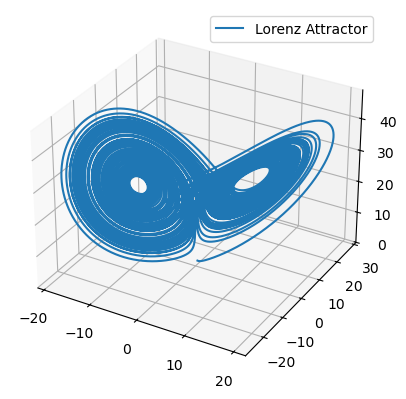

In [9]:
# Solve using odeint and plot solution

time = np.linspace(0,100,100000)
sol = odeint(Lorenz,y0 = Y_0,t = time,tfirst = True)

x_sol = sol.T[0]
y_sol = sol.T[1]
z_sol = sol.T[2]

ax = plt.figure().add_subplot(projection = '3d')

ax.plot(x_sol,y_sol,z_sol, label = 'Lorenz Attractor')
ax.legend()
plt.show()

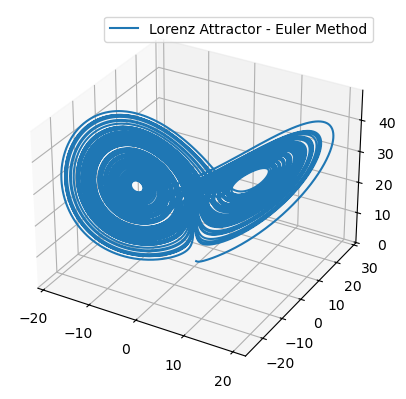

In [11]:
'''
Euler's Method for solving first order ODEs of the form y' = f(x,y) with intial condition y(0) = y_0 is given by the formula
y(i) = y(i-1) + f(x_(i-1),y_(i-1))*dx  where dx = x_(i)-x(i-1)
'''
dx = time[1]-time[0]

solution = np.zeros((3,len(time)))
solution[:,0] = Y_0

iterations = range(1,len(time))
for i in iterations:
    solution[:,i] = solution[:,i-1] + Lorenz(time[i-1],solution[:,i-1])*dx

x = solution[0]
y = solution[1]
z = solution[2]

ax = plt.figure().add_subplot(projection = '3d')
ax.plot(x,y,z, label = 'Lorenz Attractor - Euler Method')
ax.legend()
plt.show()